# USR Golden Trajectory Search (Corrected Physics)

## Objective
1. Find the optimal initial velocity $y_i$ that maximizes USR duration for a given $\xi=1000$ and initial field $\phi_i$ adjusted for sufficient e-folds.
2. Generate a high-resolution Heatmap around this "Golden Point".

## Physics Context
We use the standard definition of the Hubble slow-roll parameter:
$$\eta \equiv \frac{d \ln \epsilon_H}{dN}$$
During the transient dissipation of high kinetic energy (Kinetic Dominance -> Slow Roll transition), the field can enter an **Ultra Slow Roll (USR)** phase where $\eta \approx -6$.

In [33]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

# Add root path
root_dir = os.path.abspath('..')
if root_dir not in sys.path:
    sys.path.insert(0, root_dir)

from inflation_models import HiggsModel
from inf_dyn_background import run_background_simulation, get_derived_quantities

# Plot Settings
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

In [34]:
def get_usr_duration(y_val, phi_val, xi, lam=0.1):
    """
    Returns the duration (e-folds) of the USR phase (eta < -5).
    Includes robustness against KD starts and proper eta definition.
    """
    # Setup Model
    model = HiggsModel(lam=lam, xi=xi)
    model.phi0 = phi_val
    model.yi = y_val
    
    # Run Sim (Short duration is usually enough for transient USR, 
    # but we need enough N to verify inflation happens)
    # Max Time scaled by xi roughly
    T_max = max(100, xi/5.0)
    criteria_usr = 5.5
    try:
        sol = run_background_simulation(model, np.linspace(0, T_max, 30000))
    except:
        return 0.0

    if np.any(np.isnan(sol)):
        return 0.0

    data = get_derived_quantities(sol, model)
    N = data['N']
    eps = data['epsH']
    
    # --- Calculate Eta (Standard Definition) ---
    # eta = d ln(eps) / dN
    eta_std = 2 * eps - 2 * data['etaH'] # Exactly analytical!
    
    # --- Robust Truncation ---
    # Find the LAST index where epsilon < 1 (Inflationary phase)
    is_inflating = eps < 1.0
    if np.any(is_inflating):
        # Start tracking at the onset of inflation
        start_idx = np.where(is_inflating)[0][0]
        post_inflation = (eps[start_idx:] >= 1.0)
        if np.any(post_inflation):
            cutoff = start_idx + np.where(post_inflation)[0][0]
        else:
            cutoff = len(eps)
        
        eta_inf = eta_std[:cutoff]
        N_inf = N[:cutoff]
        
        # Identify USR (Standard Definition: eta ~ -6)
        is_usr = (eta_inf < -criteria_usr)
        if np.any(is_usr):
            dN = np.diff(N_inf, prepend=N_inf[0])
            duration = np.sum(dN[is_usr])
        else:
            duration = 0.0
            
    else:
        # Never entered inflation
        duration = 0.0
        
    return duration

In [35]:
# ==========================================
# 2. Find Optimal Velocity (Optimization)
# ==========================================

XI_TARGET = 1000.0
# Pre-adjusted Phi target for N > 55 (based on manual tests)
PHI_TARGET = 5.43

print(f"Searching for optimal velocity y_i at phi={PHI_TARGET}, xi={XI_TARGET}...")

# Objective function to MINIMIZE (negative duration)
def objective(y):
    return -get_usr_duration(y, PHI_TARGET, XI_TARGET)

# 1. Coarse Sweep
# Scan high velocities (log space)
y_sweep = -np.logspace(0, 3, 50) # -1.0 to -1000.0
durations = [get_usr_duration(y, PHI_TARGET, XI_TARGET) for y in y_sweep]

best_idx = np.argmax(durations)
best_y_guess = y_sweep[best_idx]
max_dur_guess = durations[best_idx]

print(f"Sweep Best: y ~ {best_y_guess:.2f}, Duration ~ {max_dur_guess:.4f}")

# 2. Fine Tune
res = minimize_scalar(objective, bracket=[best_y_guess*0.5, best_y_guess*1.5])
optimal_y = res.x
max_duration = -res.fun

print(f"Optimization Result:")
print(f"  Optimal y_i: {optimal_y:.5f}")
print(f"  Max USR Duration: {max_duration:.5f} e-folds")

Searching for optimal velocity y_i at phi=5.43, xi=1000.0...
Sweep Best: y ~ -1.00, Duration ~ 0.1953
Optimization Result:
  Optimal y_i: -1.17551
  Max USR Duration: 0.19533 e-folds


In [36]:
# ==========================================
# 3. High-Res Heatmap around Optimal Point
# ==========================================

# Define Window
phi_window = 0.5
phi_min, phi_max = PHI_TARGET - phi_window, PHI_TARGET + phi_window

# Velocity window: +/- 50% of optimal magnitude
y_mag = abs(optimal_y)
y_min_scan = -0.1 # slightly wider to see falloff
y_max_scan = -5

N_RES = 100
phi_grid = np.linspace(phi_min, phi_max, N_RES)
y_grid = np.linspace(y_min_scan, y_max_scan, N_RES)

print(f"\nGenerating Heatmap {N_RES}x{N_RES}...")
print(f"Phi Range: [{phi_min}, {phi_max}]")
print(f"Y Range: [{y_min_scan:.2f}, {y_max_scan:.2f}]")

grid_dur = np.zeros((N_RES, N_RES))

for i, y_val in enumerate(y_grid):
    print(f"Row {i+1}/{N_RES}...", end='\r')
    for j, phi_val in enumerate(phi_grid):
        dur = get_usr_duration(y_val, phi_val, XI_TARGET)
        grid_dur[i, j] = dur

print("\nDone.")




Generating Heatmap 100x100...
Phi Range: [4.93, 5.93]
Y Range: [-0.10, -5.00]
Row 100/100...
Done.


In [5]:
# Save Results to JSON Structure

scripts_dir = os.path.abspath(os.path.join(os.getcwd(), '..', 'scripts'))
if scripts_dir not in sys.path:
    sys.path.insert(0, scripts_dir)

from save_usr_grid_search import save_usr_grid_to_json

json_filepath = save_usr_grid_to_json(
    xi=XI_TARGET, 
    lam=0.1, 
    phi_grid=phi_grid, 
    y_grid=y_grid, 
    grid_dur=grid_dur, 
    output_dir="../outputs"
)


Results successfully saved to c:\Users\diego\OneDrive\Documentos\Universidad\Cosmologia\A-NumInflation\outputs\USR_duration_heat_5.26to6.08_yi_5.00to0.10_d17aad1f.json


In [21]:
import json

# 1. Update this to the exact filename in your outputs/ folder
filename = "USR_duration_heat_4.93to5.93_yi_10.00to0.10_7716c853.json"
filepath = f"../outputs/{filename}"

# 2. Load the JSON data
with open(filepath, 'r') as f:
    data = json.load(f)

# 3. Extract lists directly relative to their original simulation order 
phi_vals = [res['phi0'] for res in data['results']]
y_vals = [res['yi'] for res in data['results']]
dur_vals = [res['usr_duration'] for res in data['results']]

# Extract unique coordinates while preserving their original loop order
phi_grid = list(dict.fromkeys(phi_vals))
y_grid = list(dict.fromkeys(y_vals))

N_phi = len(phi_grid)
N_y = len(y_grid)

# 4. Initialize and repopulate the 2D grid
grid_dur = np.zeros((N_y, N_phi))

for idx, dur in enumerate(dur_vals):
    i = idx // N_phi  # y-axis index (outer loop)
    j = idx % N_phi   # phi-axis index (inner loop)
    grid_dur[i, j] = dur

print(f"Loaded simulation data from {data['metadata']['timestamp']}")

Loaded simulation data from 2026-03-30T00:49:17.629491


NameError: name 'data' is not defined

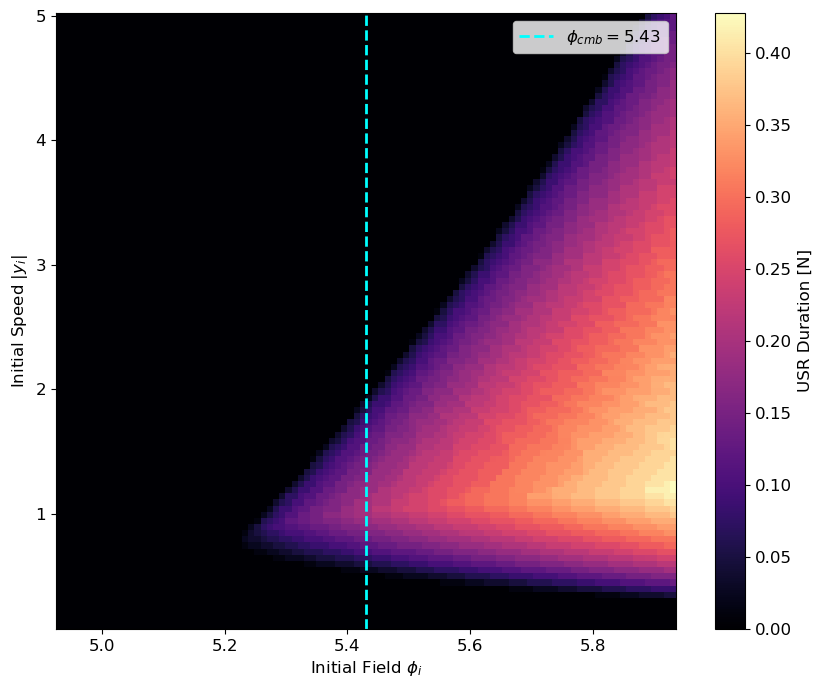

In [37]:

plt.figure(figsize=(10, 8))
X, Y = np.meshgrid(phi_grid, np.abs(y_grid))

# Plot the heatmap
plt.pcolormesh(X, Y, grid_dur, shading='auto', cmap='magma')
plt.colorbar(label='USR Duration [N]')
plt.xlabel(r'Initial Field $\phi_i$')
plt.ylabel(r'Initial Speed $|y_i|$')
#plt.title(f"Transient USR Duration \n$\\xi={data['model_parameters']['xi']}$")

# Mark CMB pivot scale
plt.axvline(x=5.43, color='cyan', linestyle='--', linewidth=2, label=r'$\phi_{cmb} = 5.43$')
plt.legend()

# ---------------------------------------------------------
# Dynamic Filename Generation & Saving
# ---------------------------------------------------------
# Extract key parameters for the filename
xi_val = data['model_parameters']['xi']
phi_min = data['grid_parameters']['phi0_min']
phi_max = data['grid_parameters']['phi0_max']
y_max = abs(data['grid_parameters']['y0_min']) # Assuming min is the largest negative velocity
y_min = abs(data['grid_parameters']['y0_max'])

# Construct a detailed filename
# Example: USR_heatmap_xi1000.0_phi5.2to5.8_y0.1to1.5.png
filename = f"USR_heatmap_xi{xi_val}_phi{phi_min:.2f}to{phi_max:.2f}_y{y_min:.2f}to{y_max:.2f}.png"

# Ensure the output directory exists
output_dir = "plots" # You can change this to "outputs" if you prefer
os.makedirs(output_dir, exist_ok=True)

# Save the plot BEFORE plt.show()
filepath = os.path.join(output_dir, filename)
plt.savefig(filepath, dpi=300, bbox_inches='tight')
print(f"Heatmap successfully saved to: {filepath}")

# Finally, display the plot inline
plt.show()


Simulating: xi=1000.0, y_i=-1.00, phi_i=5.43


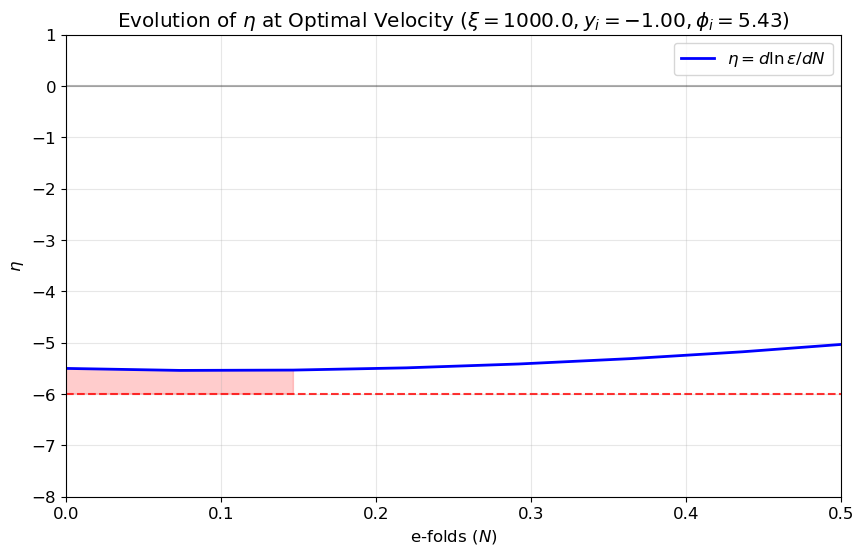

Final N total: 52.44 (Target > 55)


In [25]:
# ==========================================
# 4. Visualize Optimal Trajectory (with min N Check)
# ==========================================

def plot_usr_eta_standard_final(xi, yi, phi_start):
    print(f"Simulating: xi={xi}, y_i={yi:.2f}, phi_i={phi_start}")
    model = HiggsModel(lam=0.1, xi=xi)
    model.phi0 = phi_start
    model.yi = yi
    
    T_max = max(100, xi/5.0) 
    t_span = np.linspace(0, T_max, 5000)
    sol = run_background_simulation(model, t_span)

    data = get_derived_quantities(sol, model)
    N = data['N']
    eps = data['epsH']
    
    eta_std = 2 * data['epsH'] - 2 * data['etaH'] # Exactly analytical!
    
    if np.any(eps >= 1.0):
        end_idx = np.argmax(eps >= 1.0)
        cutoff = min(len(N), end_idx + 20)
    else:
        cutoff = len(N)
        
    N_plot = N[:cutoff]
    eps_plot = eps[:cutoff]
    eta_plot = eta_std[:cutoff]
    
    plt.figure(figsize=(10, 6))
    plt.plot(N_plot, eta_plot, label=r'$\eta = d\ln\epsilon/dN$', linewidth=2, color='blue')
    #plt.plot(N_plot, eps_plot, label=r'$\epsilon', linewidth=2, color='orange')
    plt.axhline(0, color='k', linestyle='-', alpha=0.3)
    plt.axhline(-6, color='r', linestyle='--', alpha=0.8)
    plt.fill_between(N_plot, eta_plot, -6, where=((eta_plot<-criteria_usr)&(eta_plot>-8)), color='red', alpha=0.2)
    plt.xlabel('e-folds ($N$)'); plt.ylabel(r'$\eta$')
    plt.title(rf'Evolution of $\eta$ at Optimal Velocity ($\xi={xi}, y_i={yi:.2f}, \phi_i={phi_start}$)')
    plt.legend(); plt.grid(True, alpha=0.3); plt.ylim(-8, 1)
    plt.xlim(0,0.5)
    plt.show()
    
    print(rf"Final N total: {N_plot[-1]:.2f} (Target > 55)")

plot_usr_eta_standard_final(XI_TARGET, -1, 5.43)